<a href="https://colab.research.google.com/github/Maria2007-collab/CURSO-DE-INTRO-DE-DATOS-ESPACIALES/blob/main/EXAMEN1%20" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **EXAMEN INDIVIDUAL 1**
Nombre: María Saldaña Ruiz

Código:20241445

**Objetivo de la Tarea**
El objetivo principal de este trabajo es procesar, integrar y representar visualmente información estadística y geográfica mediante el uso de librerías geoespaciales en Python (GeoPandas y Matplotlib), elaborando diferentes tipos de mapas temáticos (coropletas, densidad de puntos y símbolos proporcionales) para analizar la distribución y penetración de usuarios de telefonía móvil en el continente americano.

**Breve Descripción del examen**
En esta práctica se realiza la unión (merge) entre una base de datos tabular (some_dataworld.csv), que contiene indicadores sociodemográficos y de telecomunicaciones, y una capa vectorial geoespacial (worldMaps.gpkg) que delimita los países del mundo.

A partir de este proceso, se delimita el área de estudio a 31 países de América (Norteamérica, Centroamérica, el Caribe y Sudamérica) para construir tres modelos cartográficos comparativos.

Abro las librerias geopandas (trabaja con datos geográficos para los mapas) y pandas (trabaja con datos tabulares). Subo los archivos y leo los datos. El GeoPackage contiene información geográfica y seleccioné la capa countries porque es la que contiene los países que necesito para elaborar los mapas.

In [10]:
from google.colab import files
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

# Subir archivos
uploaded = files.upload()

# Leer los datos
df = pd.read_csv(
    "some_dataworld.csv",
    on_bad_lines="skip"
)

gdf = gpd.read_file(
    "worldMaps.gpkg",
    layer="countries"
)

print("CSV:", df.shape)
print("GeoDataFrame:", gdf.shape)

Saving some_dataworld.csv to some_dataworld (1).csv
Saving worldMaps.gpkg to worldMaps (1).gpkg
CSV: (171, 10)
GeoDataFrame: (252, 2)


Selecciono los países que me pide el ejercicio y realizo la unión de ambos archivos con MERGE. Pero antes encontre que algunos nombres de los países estaban denominados de distinta forma en ambos archivos eso hacía que al realizar los mapas esos países desaparecieran, por ello tuve que estandarizar los nombres de los países porque el CSV y el GeoPackage utilizaban algunas denominaciones diferentes. Reemplacé esos nombres y los convertí a mayúsculas para poder realizar correctamente la unión entre las tablas.

In [11]:
# Regiones de América solicitadas
regiones = [
    "NORTH AMERICA",
    "SOUTH AMERICA",
    "CENTRAL AMERICA AND THE CARIBBEAN"
]

# Filtrar los países de América
df_america = df[
    df["region"].isin(regiones)
].copy()

# Crear una columna común para unir los archivos
df_america["country_join"] = df_america["Country"].replace({
    "BAHAMAS (THE)": "BAHAMAS",
    "BOLIVIA (PLURINATIONAL STATE OF)": "BOLIVIA",
    "DOMINICAN REPUBLIC (THE)": "DOMINICAN REPUBLIC"
}).str.upper()

gdf["country_join"] = gdf["COUNTRY"].str.upper()

# Unir tabla y mapa
geo_df = gdf.merge(
    df_america,
    on="country_join",
    how="inner"
)

# Comprobación
print("Países en el CSV:", len(df_america))
print("Países después de la unión:", len(geo_df))

display(
    geo_df[
        ["COUNTRY", "region", "mobiles"]
    ].sort_values("COUNTRY")
)

Países en el CSV: 31
Países después de la unión: 31


,COUNTRY,region,mobiles
0,Antigua and Barbuda,CENTRAL AMERICA AND THE CARIBBEAN,184000
1,Argentina,SOUTH AMERICA,62700000
3,Bahamas,CENTRAL AMERICA AND THE CARIBBEAN,400000
2,Barbados,CENTRAL AMERICA AND THE CARIBBEAN,323000
4,Belize,CENTRAL AMERICA AND THE CARIBBEAN,264000
5,Bolivia,SOUTH AMERICA,12000000
6,Brazil,SOUTH AMERICA,213000000
7,Canada,NORTH AMERICA,36500000
8,Chile,SOUTH AMERICA,26700000
9,Colombia,SOUTH AMERICA,87400000


El mapa coroplético representa los valores mediante diferentes intensidades de color para cada país.

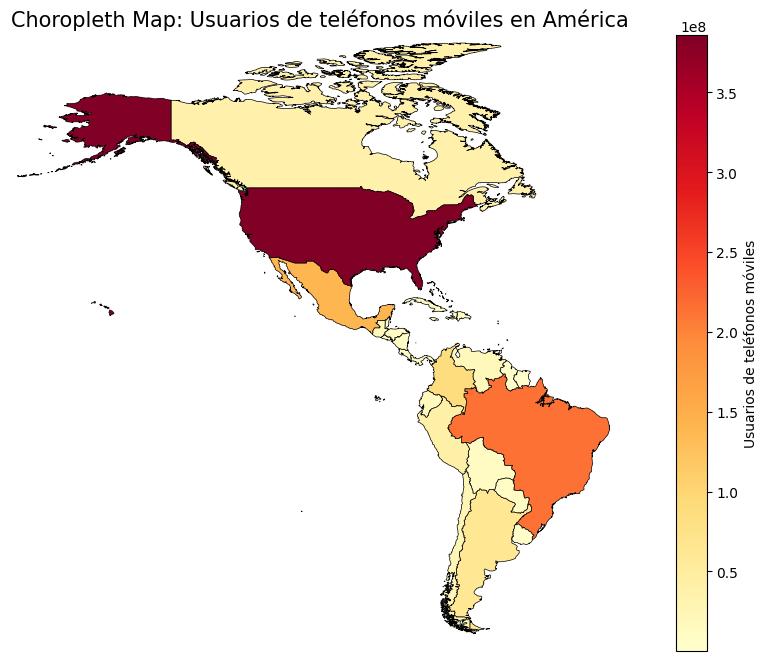

<Figure size 640x480 with 0 Axes>

In [18]:
# CHOROPLETH MAP

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 8))

geo_df.plot(
    column="mobiles",
    cmap="YlOrRd",
    legend=True,
    edgecolor="black",
    linewidth=0.5,
    ax=ax,
    legend_kwds={
        "label": "Usuarios de teléfonos móviles"
    }
)

ax.set_title(
    "Choropleth Map: Usuarios de teléfonos móviles en América",
    fontsize=15
)

ax.set_xlim(-180, -30)
ax.set_ylim(-60, 85)

ax.axis("off")

plt.show()

plt.savefig("mapa_coropletas.png", dpi=300, bbox_inches="tight")

"TO CRS" lo utilicé para transformar las geometrías a otro sistema de coordenadas que facilita la representación y el cálculo de posiciones en el mapa. EPSG:3857 es una proyección muy utilizada para representar mapas en sistemas digitales. Cada punto representa una cantidad determinada de la variable analizada; por eso una mayor concentración de puntos representa un valor mayor.

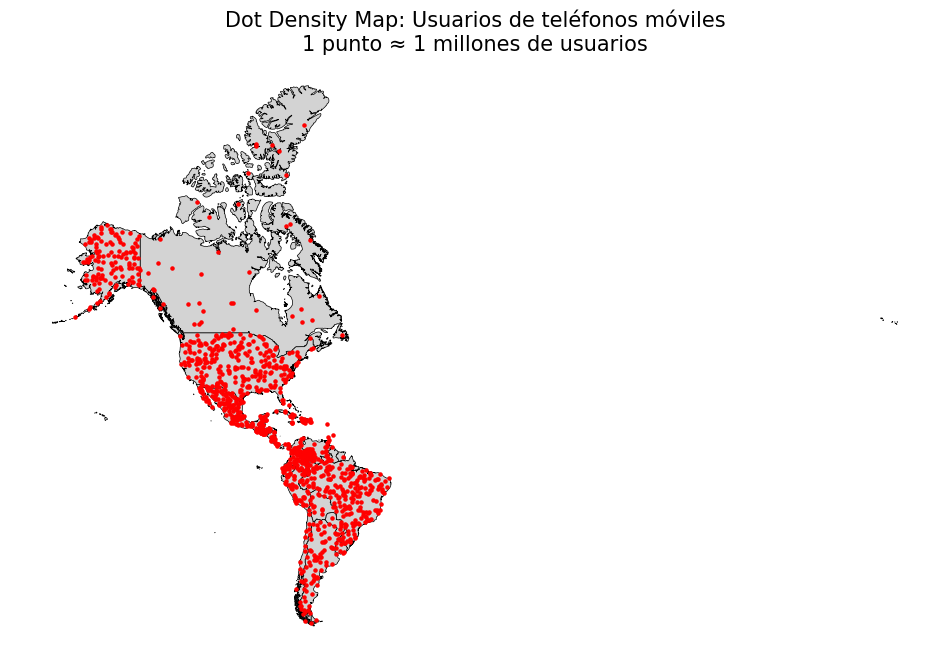

<Figure size 640x480 with 0 Axes>

In [19]:
# DOT DENSITY MAP

import geopandas as gpd
import matplotlib.pyplot as plt

geo_proj = geo_df.to_crs(epsg=3857).copy()

# Cada punto representa aproximadamente 1 millon
geo_proj["n_dots"] = (
    geo_proj["mobiles"] / 1_000_000
).round().clip(lower=1).astype(int)

puntos = geo_proj.geometry.sample_points(
    size=geo_proj["n_dots"],
    rng=42
)

dots = gpd.GeoDataFrame(
    geometry=puntos,
    crs=geo_proj.crs
).explode(ignore_index=True)

fig, ax = plt.subplots(figsize=(12, 8))

geo_proj.plot(
    ax=ax,
    color="lightgray",
    edgecolor="black",
    linewidth=0.5
)

dots.plot(
    ax=ax,
    color="red",
    markersize=5
)

ax.set_title(
    "Dot Density Map: Usuarios de teléfonos móviles\n"
    "1 punto ≈ 1 millones de usuarios",
    fontsize=15
)

ax.axis("off")

plt.show()

plt.savefig("mapa_densidad.png", dpi=300, bbox_inches="tight")

El mapa de símbolos proporcionales representa los valores mediante símbolos cuyo tamaño cambia según la magnitud de la variable.

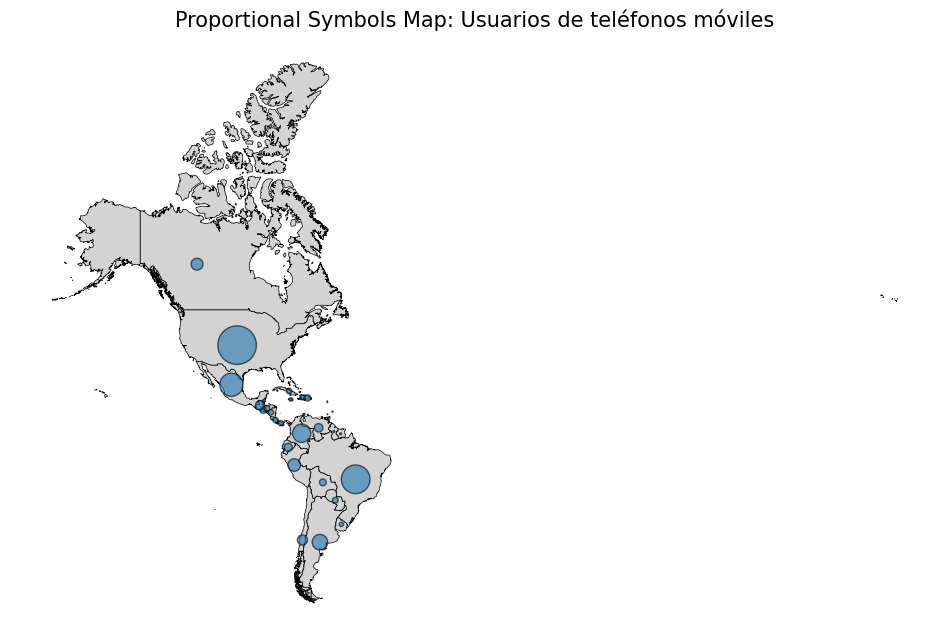

<Figure size 640x480 with 0 Axes>

In [20]:
import matplotlib.pyplot as plt

centros = geo_proj.representative_point()

fig, ax = plt.subplots(figsize=(12, 8))

geo_proj.plot(
    ax=ax,
    color="lightgray",
    edgecolor="black",
    linewidth=0.5
)

ax.scatter(
    centros.x,
    centros.y,
    s=geo_proj["mobiles"] / 500_000,
    alpha=0.6,
    edgecolors="black"
)

ax.set_title(
    "Proportional Symbols Map: Usuarios de teléfonos móviles",
    fontsize=15
)

ax.axis("off")

plt.show()

plt.savefig("mapa_simbolos.png", dpi=300, bbox_inches="tight")

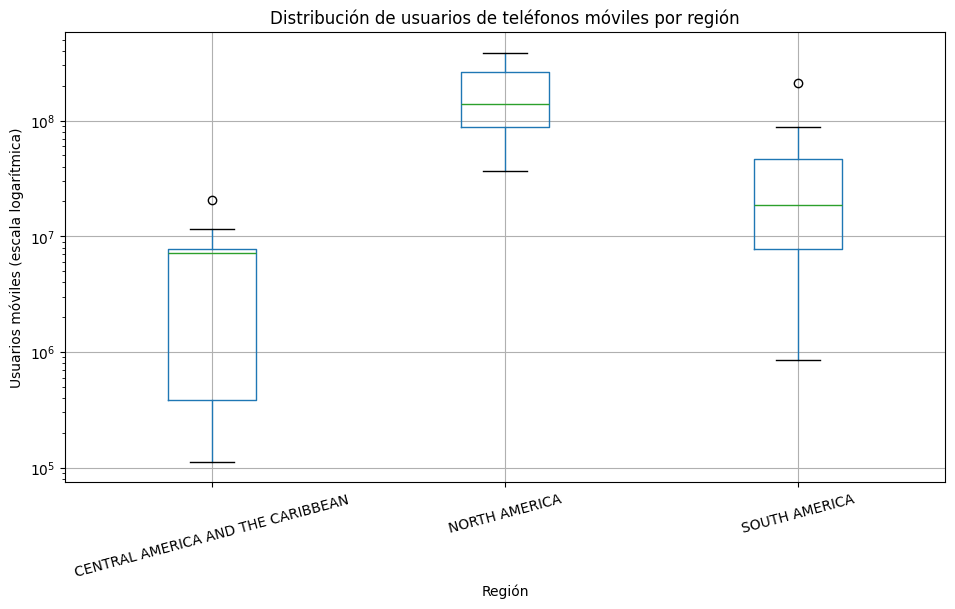

,COUNTRY,region,population,mobiles
28,United States,NORTH AMERICA,341963408,386000000
6,Brazil,SOUTH AMERICA,220051512,213000000
21,Mexico,NORTH AMERICA,130739927,140000000
9,Colombia,SOUTH AMERICA,49588357,87400000
1,Argentina,SOUTH AMERICA,46994384,62700000
25,Peru,SOUTH AMERICA,32600249,41300000
7,Canada,NORTH AMERICA,38794813,36500000
8,Chile,SOUTH AMERICA,18664652,26700000
16,Guatemala,CENTRAL AMERICA AND THE CARIBBEAN,18255216,20600000
30,Venezuela,SOUTH AMERICA,31250306,18800000


In [15]:
# =====================================================
# DIAGRAMA DE CAJAS
# =====================================================

fig, ax = plt.subplots(figsize=(11, 6))

df_america.boxplot(
    column="mobiles",
    by="region",
    ax=ax
)

ax.set_yscale("log")

ax.set_title(
    "Distribución de usuarios de teléfonos móviles por región"
)

ax.set_xlabel("Región")
ax.set_ylabel("Usuarios móviles (escala logarítmica)")

plt.suptitle("")
plt.xticks(rotation=15)

plt.show()


# =====================================================
# TABLA FINAL
# =====================================================

display(
    geo_df[
        ["COUNTRY", "region", "population", "mobiles"]
    ].sort_values(
        "mobiles",
        ascending=False
    )
)

In [21]:
from google.colab import files
files.download("mapa_coropletas.png")
files.download("mapa_densidad.png")
files.download("mapa_simbolos.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>